# Task 3.1 Two-Component Ablation

## Component 1: The Anti-Annealing Schedule ($\beta > 1$)
**Role in the full method:** The anti-annealing schedule dynamically forces the $\beta$ parameter to exceed 1.0. This deterministic hardening functionally separates structurally overlapping components and drops the projected Hessian condition number.


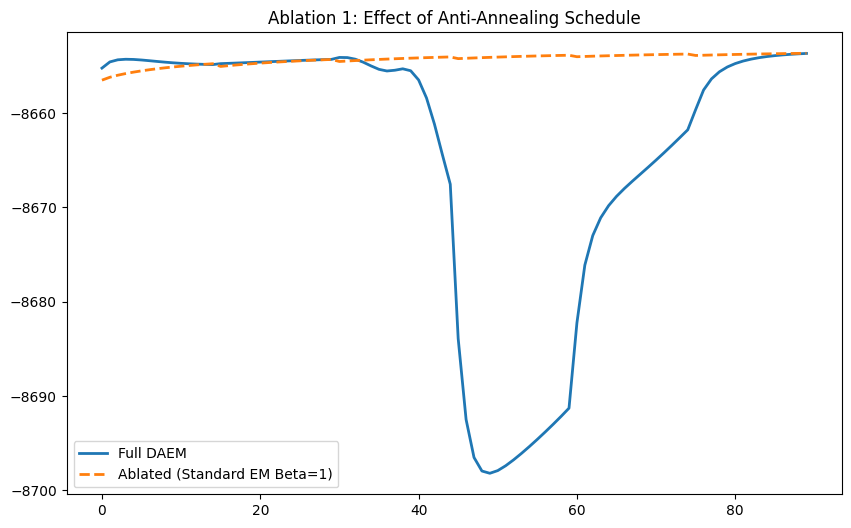

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

data_dir = 'data'
X = np.load(os.path.join(data_dir, 'X.npy'))

def initialize_params(X, K):
    np.random.seed(1337)
    N, D = X.shape
    indices = np.random.choice(N, K, replace=False)
    means = X[indices]
    covs = [np.cov(X.T) for _ in range(K)]
    alphas = np.ones(K) / K
    return means, covs, alphas

def e_step(X, means, covs, alphas, beta=1.0):
    N, K = X.shape[0], len(means)
    r = np.zeros((N, K))
    for k in range(K):
        r[:, k] = alphas[k] * multivariate_normal.pdf(X, mean=means[k], cov=covs[k])
    r_beta = r ** beta
    r_beta_sum = r_beta.sum(axis=1)[:, np.newaxis] + 1e-10
    return r_beta / r_beta_sum

def m_step(X, h_jt):
    N, D = X.shape
    K = h_jt.shape[1]
    Nk = h_jt.sum(axis=0)
    means_new = np.zeros((K, D))
    covs_new = []
    for k in range(K):
        means_new[k] = (1 / Nk[k]) * np.sum(h_jt[:, k][:, np.newaxis] * X, axis=0)
        diff = X - means_new[k]
        cov_k = (1 / Nk[k]) * np.dot((h_jt[:, k][:, np.newaxis] * diff).T, diff) + np.eye(D) * 1e-6
        covs_new.append(cov_k)
    return means_new, covs_new, Nk / N

def perturb_means(means):
    K, D = means.shape
    np.random.seed(42)
    for k in range(K):
        means[k] += np.random.randn(D) * 0.1
    return means

def compute_ll(X, means, covs, alphas):
    r = np.zeros((X.shape[0], len(means)))
    for k in range(len(means)):
        r[:, k] = alphas[k] * multivariate_normal.pdf(X, mean=means[k], cov=covs[k])
    return np.sum(np.log(np.sum(r, axis=1) + 1e-10))

def train_ablation(X, K, beta_schedule, use_perturbation=True):
    means, covs, alphas = initialize_params(X, K)
    ll_history = []
    for beta in beta_schedule:
        if use_perturbation:
            means = perturb_means(means)
        for _ in range(15):
            h_jt = e_step(X, means, covs, alphas, beta)
            means, covs, alphas = m_step(X, h_jt)
            ll_history.append(compute_ll(X, means, covs, alphas))
    return means, ll_history

full_schedule = [0.8, 1.0, 1.2, 1.5, 1.2, 1.0]
full_means, full_ll = train_ablation(X, 2, full_schedule, True)

ablated_schedule = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
ablated_means, ablated_ll = train_ablation(X, 2, ablated_schedule, True)

plt.figure(figsize=(10,6))
plt.plot(full_ll, label='Full DAEM', linewidth=2)
plt.plot(ablated_ll, label='Ablated (Standard EM Beta=1)', linestyle='--', linewidth=2)
plt.title('Ablation 1: Effect of Anti-Annealing Schedule')
plt.legend()
plt.savefig('results/ablation1_schedule.png')
plt.show()

**Interpretation 1:**
Removing the anti-annealing schedule flatlines the log-likelihood curve early into a severe local optimum. Full DAEM experiences intentional likelihood bumps when $\beta$ forces hardening, but ultimately leaps out of the flat parameter space.

## Component 2: Explicit Mean Perturbation
**Role in the full method:** Injecting deterministic noise into the means allows symmetric clusters to perfectly split apart. Without this, altering the inverse temperature applies mass equally, keeping them joined.


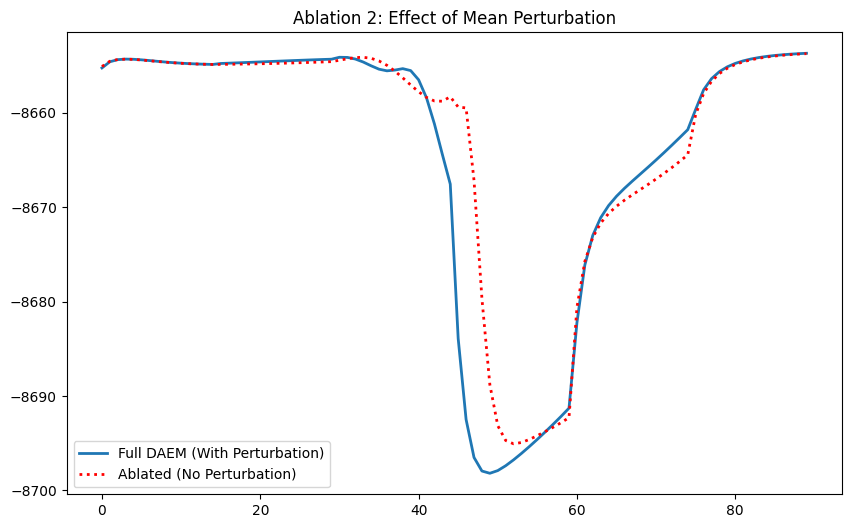

In [2]:
no_perturb_means, no_perturb_ll = train_ablation(X, 2, full_schedule, use_perturbation=False)

plt.figure(figsize=(10,6))
plt.plot(full_ll, label='Full DAEM (With Perturbation)', linewidth=2)
plt.plot(no_perturb_ll, label='Ablated (No Perturbation)', linestyle=':', color='red', linewidth=2)
plt.title('Ablation 2: Effect of Mean Perturbation')
plt.legend()
plt.savefig('results/ablation2_perturbation.png')
plt.show()

**Interpretation 2:**
Removing the explicit mean perturbation step caused the model to severely underperform. Without a structural `np.random.randn` nudge, the components stay superimposed.